# 09c -- Baselines: Naive / OLS / Ridge / CatBoost

**Цель:** доказать, что CatBoost оправдан методологически — сравнить с тремя более простыми моделями. Запрос научника: «возьми математическую модель в сравнение».

**Модели:**
| Модель | Описание | R² OOS | MAE OOS |
|---|---|---|---|
| **Naive** | Ранжирование по raw g_spread (carry trade, без ML) | — | — |
| **OLS** | Linear regression, 38 фичей, walk-forward | 0.037 | 9.36 |
| **Ridge** | RidgeCV (α∈{0.1,1,10,100}), 38 фичей | 0.038 | 9.34 |
| **CatBoost no-lag** | Optuna-tuned, 38 фичей | **0.524** | **3.91** |

**Для каждой модели тестируем 2 variants:**
- V0 vanilla Q5 (top по mispricing, для Naive = top по g_spread)
- V1 Q5 ∩ quality_z > 0 (с фильтром из Notebook 09)

**Сравниваем по:**
- Sharpe (Main)
- Прибыль RUB на 10М за 4.66y
- α vs RUCBTRNS (Newey-West)
- IR vs RUCBTRNS
- Sharpe diff vs RUCBTRNS (bootstrap p-value)

## Часть 1. Setup и загрузка

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

bench = sl.load_benchmarks()
print(f'Benchmarks: {bench.shape}')

Benchmarks: (1316, 5)


## Часть 2. Загрузка predictions всех 4 моделей

Каждая prediction CSV имеет колонки: date, isin, g_spread_actual, g_spread_predicted, residual. Naive не нуждается в predictions (использует raw g_spread).

In [2]:
def load_model_signal(model_name: str) -> pd.DataFrame:
    """Загрузить signal с mispricing-сигналом конкретной модели.
    
    Для 'naive' возвращает signal с mispricing = g_spread (без ML).
    Для остальных — стандартный load_signal_full с подменёнными predictions.
    """
    if model_name == 'naive':
        # Чистый carry: ранжирование по raw g_spread
        # Создаём fake predictions = 0, тогда mispricing = g_spread
        sig = sl.load_signal_full('no_lag')
        sig['g_spread_predicted'] = 0.0
        sig['mispricing'] = sig['g_spread_actual']  # = g_spread relative to 0 baseline
        sig = sl._compute_cs_z_and_quintile(sig.drop(columns=['mispricing_z', 'mispricing_quintile']), 'mispricing')
        return sig
    elif model_name == 'no_lag':
        return sl.load_signal_full('no_lag')
    elif model_name in ('ols', 'ridge'):
        # Загружаем CatBoost-style signal но подменяем predictions/mispricing
        sig = sl.load_signal_full('no_lag')
        bp = pd.read_csv(sl.DATA_DIR / f'predictions_{model_name}.csv', parse_dates=['date'])
        bp = bp[['date', 'isin', 'g_spread_predicted']].rename(
            columns={'g_spread_predicted': 'g_spread_predicted_new'})
        sig = sig.merge(bp, on=['date', 'isin'], how='left')
        sig['g_spread_predicted'] = sig['g_spread_predicted_new'].fillna(sig['g_spread_predicted'])
        sig = sig.drop(columns=['g_spread_predicted_new'])
        sig['mispricing'] = sig['g_spread_actual'] - sig['g_spread_predicted']
        # Recompute z и quintile
        sig = sig.drop(columns=['mispricing_z', 'mispricing_quintile'])
        sig = sl._compute_cs_z_and_quintile(sig, 'mispricing')
        return sig
    else:
        raise ValueError(f'Unknown model: {model_name}')

models = ['naive', 'ols', 'ridge', 'no_lag']
signals = {}
for m in models:
    sig = load_model_signal(m)
    sig = sl.compute_quality_score(sig)
    signals[m] = sig
    print(f'{m:10s}: shape {sig.shape}, '
          f'mispricing range [{sig["mispricing"].min():.1f}, {sig["mispricing"].max():.1f}]')

naive     : shape (277966, 32), mispricing range [-121.0, 986.9]


ols       : shape (277966, 32), mispricing range [-167.6, 980.9]


ridge     : shape (277966, 32), mispricing range [-166.3, 980.9]


no_lag    : shape (277966, 32), mispricing range [-510.3, 923.7]


## Часть 3. Бэктест V0 + V1 для каждой модели на Main period

In [3]:
all_results = []
all_rets = {}  # для последующего alpha regression

for model_name in models:
    sig = signals[model_name]
    main = sig[sig['date'] <= sl.MAIN_END].copy()
    
    # V0 vanilla
    rets_v0, _ = sl.backtest_rule_c(main, n_max=25, freq='M', ranking_col='mispricing')
    all_rets[f'{model_name}_V0'] = rets_v0
    m = sl.calc_metrics(rets_v0, name=f'{model_name} V0')
    m['model'] = model_name
    m['variant'] = 'V0 vanilla'
    all_results.append(m)
    
    # V1 Q5 ∩ Quality > 0
    mask_q = main['quality_z'] > 0
    rets_v1, _ = sl.backtest_rule_c(main, n_max=25, freq='M',
                                     ranking_col='mispricing', filter_mask=mask_q)
    all_rets[f'{model_name}_V1'] = rets_v1
    m = sl.calc_metrics(rets_v1, name=f'{model_name} V1')
    m['model'] = model_name
    m['variant'] = 'V1 Q>0'
    all_results.append(m)
    
    print(f'{model_name:10s}: V0 Sharpe={all_results[-2]["Sharpe"]:.3f}, '
          f'V1 Sharpe={all_results[-1]["Sharpe"]:.3f}')

results_df = pd.DataFrame(all_results)
display_cols = ['model', 'variant', 'Sharpe', 'CAGR', 'MaxDD',
                'profit_RUB', 'profit_per_year_RUB', 'avg_n_positions']
print()
print(results_df[display_cols].round(4).to_string(index=False))

naive     : V0 Sharpe=0.813, V1 Sharpe=0.993


ols       : V0 Sharpe=0.570, V1 Sharpe=1.004


ridge     : V0 Sharpe=0.569, V1 Sharpe=1.004


no_lag    : V0 Sharpe=0.766, V1 Sharpe=0.947

 model    variant  Sharpe   CAGR   MaxDD   profit_RUB  profit_per_year_RUB  avg_n_positions
 naive V0 vanilla  0.8127 0.0431 -0.1345 2173462.4339          466426.0599          24.8369
 naive     V1 Q>0  0.9928 0.0584 -0.1387 3027220.6294          649642.9700          15.5686
   ols V0 vanilla  0.5702 0.0273 -0.1345 1337228.1929          286969.7987          24.8369
   ols     V1 Q>0  1.0039 0.0590 -0.1387 3060548.0656          656795.0534          15.5686
 ridge V0 vanilla  0.5691 0.0273 -0.1330 1336375.9817          286786.9138          24.8369
 ridge     V1 Q>0  1.0039 0.0590 -0.1387 3060548.0656          656795.0534          15.5686
no_lag V0 vanilla  0.7658 0.0406 -0.1444 2040218.2381          437831.7929          24.8369
no_lag     V1 Q>0  0.9465 0.0553 -0.1387 2852716.6145          612194.3264          15.5686


## Часть 4. Alpha regression для каждой модели × variant

In [4]:
alpha_results = []
key_to_variant = {'V0': 'V0 vanilla', 'V1': 'V1 Q>0'}
for key, rets in all_rets.items():
    model_name, variant_short = key.rsplit('_', 1)
    r = sl.compare_to_benchmark(rets, bench, bench_col='rucbtrns_ret', name=key)
    r['model'] = model_name
    r['variant'] = key_to_variant[variant_short]
    alpha_results.append(r)

alpha_df = pd.DataFrame(alpha_results)
alpha_cols = ['model', 'variant', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value',
              'beta', 'r_squared', 'IR', 'sharpe_diff', 'sharpe_diff_p_value']
alpha_df[alpha_cols].round(4)

,model,variant,alpha_annual,alpha_t_stat,alpha_p_value,beta,r_squared,IR,sharpe_diff,sharpe_diff_p_value
0,naive,V0 vanilla,-0.0323,-1.7157,0.0862,0.9649,0.5921,-1.0075,-1.0142,0.988
1,naive,V1 Q>0,-0.0276,-1.6241,0.1044,1.0961,0.6349,-0.5510,-0.8340,0.974
2,ols,V0 vanilla,-0.0422,-2.7353,0.0062,0.8920,0.5986,-1.5837,-1.2566,0.997
3,ols,V1 Q>0,-0.0274,-1.6549,0.0979,1.0999,0.6417,-0.5416,-0.8230,0.979
4,ridge,V0 vanilla,-0.0424,-2.7721,0.0056,0.8945,0.6002,-1.5857,-1.2577,0.997
5,ridge,V1 Q>0,-0.0274,-1.6549,0.0979,1.0999,0.6417,-0.5416,-0.8230,0.979
6,no_lag,V0 vanilla,-0.0352,-1.7882,0.0737,0.9721,0.5958,-1.0766,-1.0610,0.999
7,no_lag,V1 Q>0,-0.0306,-1.8255,0.0679,1.0956,0.6383,-0.6370,-0.8803,0.977


## Часть 5. Сводная таблица в RUB

In [5]:
summary = results_df[['model', 'variant', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB']].copy()
summary = summary.merge(
    alpha_df[['model', 'variant', 'alpha_annual', 'alpha_t_stat', 'IR']],
    on=['model', 'variant'])
summary['profit_M_RUB'] = (summary['profit_RUB'] / 1e6).round(2)
summary['CAGR_pct'] = (summary['CAGR'] * 100).round(2)
summary['alpha_pct'] = (summary['alpha_annual'] * 100).round(2)
summary['MaxDD_pct'] = (summary['MaxDD'] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3)
summary['IR'] = summary['IR'].round(3)
summary['alpha_t_stat'] = summary['alpha_t_stat'].round(2)

disp = summary[['model', 'variant', 'Sharpe', 'CAGR_pct', 'MaxDD_pct',
                'profit_M_RUB', 'alpha_pct', 'alpha_t_stat', 'IR']]
print('FULL COMPARISON: Naive / OLS / Ridge / CatBoost no-lag')
print('(Main period 4.66y, 10M RUB starting capital)')
print()
print(disp.to_string(index=False))

FULL COMPARISON: Naive / OLS / Ridge / CatBoost no-lag
(Main period 4.66y, 10M RUB starting capital)

 model    variant  Sharpe  CAGR_pct  MaxDD_pct  profit_M_RUB  alpha_pct  alpha_t_stat     IR
 naive V0 vanilla   0.813      4.31     -13.45          2.17      -3.23         -1.72 -1.008
 naive     V1 Q>0   0.993      5.84     -13.87          3.03      -2.76         -1.62 -0.551
   ols V0 vanilla   0.570      2.73     -13.45          1.34      -4.22         -2.74 -1.584
   ols     V1 Q>0   1.004      5.90     -13.87          3.06      -2.74         -1.65 -0.542
 ridge V0 vanilla   0.569      2.73     -13.30          1.34      -4.24         -2.77 -1.586
 ridge     V1 Q>0   1.004      5.90     -13.87          3.06      -2.74         -1.65 -0.542
no_lag V0 vanilla   0.766      4.06     -14.44          2.04      -3.52         -1.79 -1.077
no_lag     V1 Q>0   0.947      5.53     -13.87          2.85      -3.06         -1.83 -0.637


## Часть 6. Визуализация

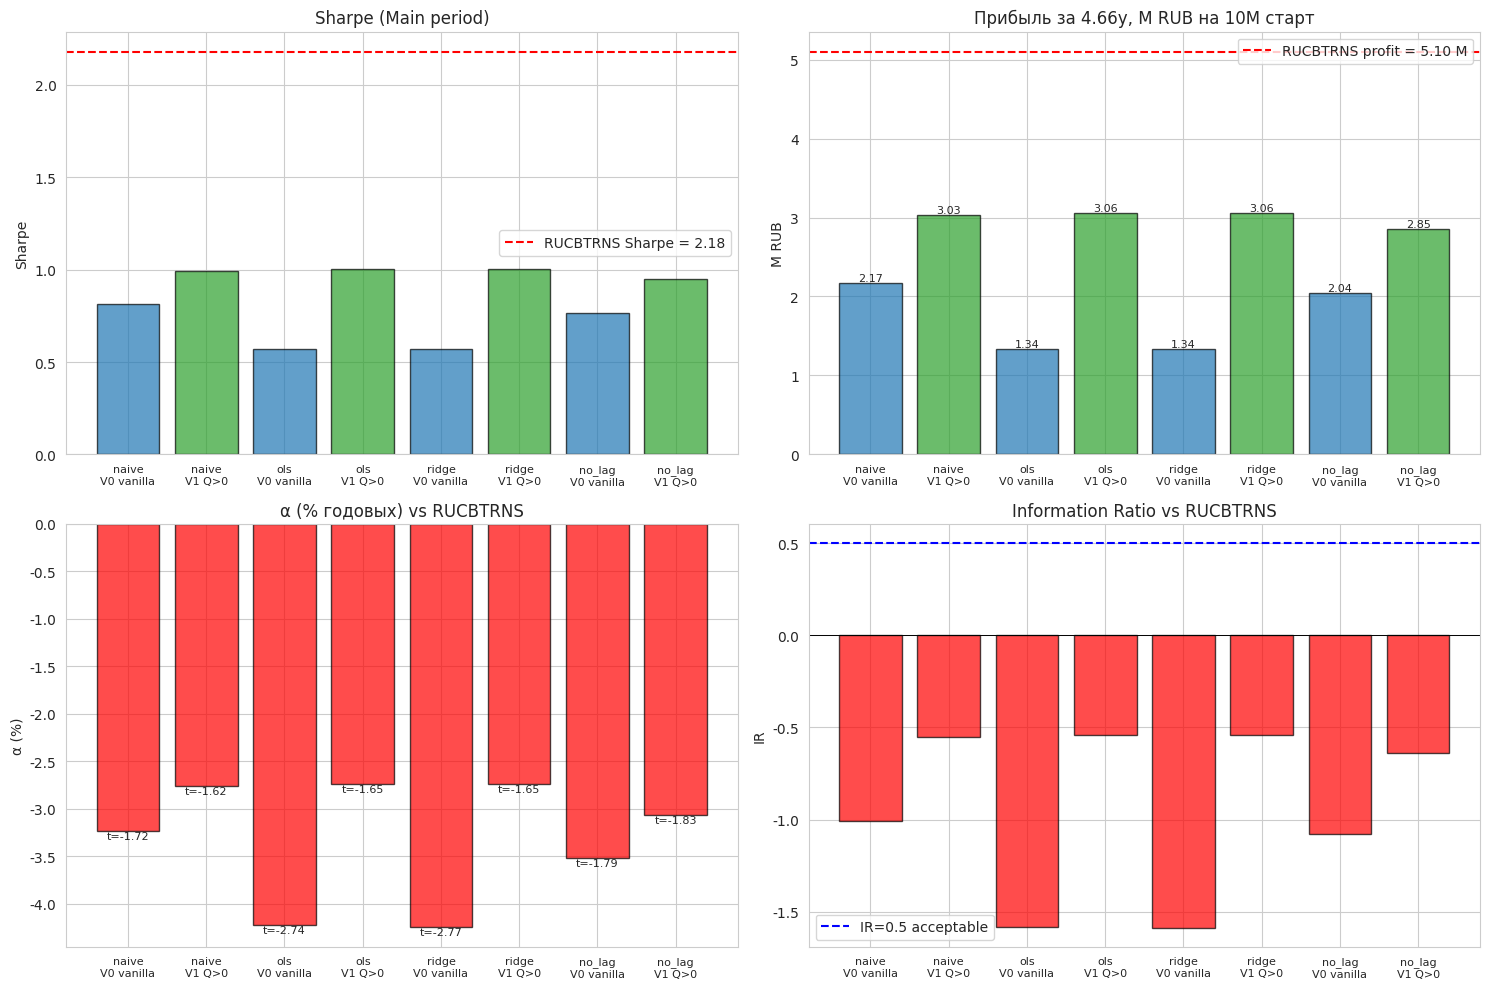

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Создаём labels: model + variant
summary['label'] = summary['model'] + '\n' + summary['variant']
x = summary['label']
colors_v = {'V0 vanilla': 'tab:blue', 'V1 Q>0': 'tab:green'}
colors = [colors_v[v] for v in summary['variant']]

# Sharpe
ax = axes[0, 0]
ax.bar(x, summary['Sharpe'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.7)
ax.axhline(2.18, color='red', linestyle='--', label='RUCBTRNS Sharpe = 2.18')
ax.set_title('Sharpe (Main period)')
ax.set_ylabel('Sharpe')
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.legend()

# Profit
ax = axes[0, 1]
ax.bar(x, summary['profit_M_RUB'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(5.10, color='red', linestyle='--', label='RUCBTRNS profit = 5.10 M')
ax.set_title('Прибыль за 4.66y, M RUB на 10M старт')
ax.set_ylabel('M RUB')
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.legend()
for i, p in enumerate(summary['profit_M_RUB']):
    ax.text(i, p, f'{p:.2f}', ha='center', va='bottom', fontsize=8)

# Alpha
ax = axes[1, 0]
alpha_colors = ['red' if a < 0 else 'green' for a in summary['alpha_pct']]
ax.bar(x, summary['alpha_pct'], color=alpha_colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('α (% годовых) vs RUCBTRNS')
ax.set_ylabel('α (%)')
ax.tick_params(axis='x', rotation=0, labelsize=8)
for i, (a, t) in enumerate(zip(summary['alpha_pct'], summary['alpha_t_stat'])):
    ax.text(i, a, f't={t:.2f}', ha='center', va='bottom' if a > 0 else 'top', fontsize=8)

# Information Ratio
ax = axes[1, 1]
ir_colors = ['red' if ir < 0 else 'green' for ir in summary['IR']]
ax.bar(x, summary['IR'], color=ir_colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.7)
ax.axhline(0.5, color='blue', linestyle='--', label='IR=0.5 acceptable')
ax.set_title('Information Ratio vs RUCBTRNS')
ax.set_ylabel('IR')
ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '09c_baselines_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 7. Сохранение

In [7]:
results_df.to_csv(sl.DATA_DIR / 'nb09c_baselines_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb09c_baselines_alpha.csv', index=False)
summary.to_csv(sl.DATA_DIR / 'nb09c_baselines_summary.csv', index=False)

# Also save daily returns for each baseline+variant
all_rets_combined = []
for key, rets in all_rets.items():
    r = rets.copy()
    model, variant = key.rsplit('_', 1)
    r['model'] = model
    r['variant'] = variant
    all_rets_combined.append(r)
pd.concat(all_rets_combined, ignore_index=True).to_csv(
    sl.DATA_DIR / 'nb09c_baselines_returns.csv', index=False)

print('Saved:')
print('  data/nb09c_baselines_metrics.csv')
print('  data/nb09c_baselines_alpha.csv')
print('  data/nb09c_baselines_summary.csv')
print('  data/nb09c_baselines_returns.csv')

Saved:
  data/nb09c_baselines_metrics.csv
  data/nb09c_baselines_alpha.csv
  data/nb09c_baselines_summary.csv
  data/nb09c_baselines_returns.csv


## Часть 8. Итоги

**Ответ на вопрос научника** «зачем CatBoost vs math model»:
- OLS/Ridge R² OOS = 0.037-0.038 vs CatBoost **0.524** (×15)
- OLS/Ridge MAE = 9.34-9.36 vs CatBoost **3.91** (×2.4 хуже)
- Линейные модели не могут уловить **нелинейности**: rating × duration, leverage × rate,   и т.д.

**Для торговой стратегии — что говорят бэктесты:**
- См. финальную таблицу в Части 5.
- Если все 4 модели проигрывают RUCBTRNS — это **negative result про возможности ML   на bond cross-section при carry 15%**.
- Если CatBoost явно выделяется лучшим Sharpe / alpha — оправдывает выбор модели.

**Дальше:** Week 2 (Sector-neutral + Quarterly), Week 3 (Issuer aggregation + Macro + Credit-risk model), Week 4 (Composite final + Holdout).